In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/PS_20174392719_1491204439457_log.csv')
print(df.shape)
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [3]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True)*100

print(fraud_counts)
print(f"\nFraud Rate: {fraud_pct[1]:.4f}%")

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Rate: 0.1291%


          fraud_count  total_count  fraud_rate
type                                          
TRANSFER         4097       532909    0.007688
CASH_OUT         4116      2237500    0.001840
CASH_IN             0      1399284    0.000000
DEBIT               0        41432    0.000000
PAYMENT             0      2151495    0.000000


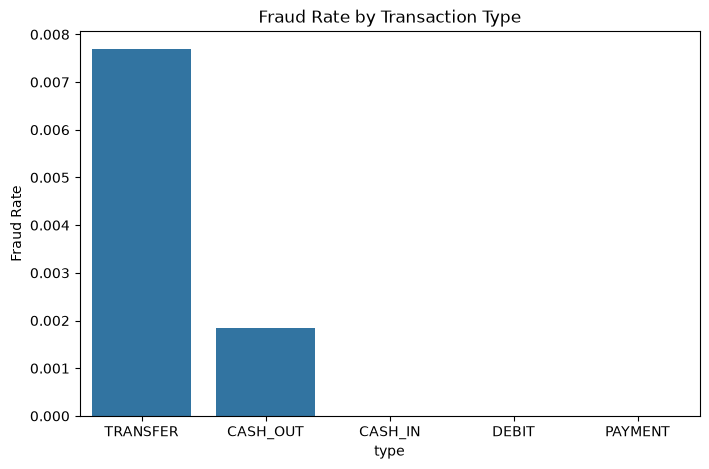

In [7]:
type_fraud = df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean']).sort_values('mean', ascending=False)
type_fraud.columns = ['fraud_count', 'total_count', 'fraud_rate']
print(type_fraud)

plt.figure(figsize=(8,5))
sns.barplot(x=type_fraud.index, y=type_fraud['fraud_rate'])
plt.title('Fraud Rate by Transaction Type')
plt.ylabel('Fraud Rate')
plt.show()

In [4]:
# Flag where the origin balance doesn't reconcile after the transaction
df['orig_balance_error'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['dest_balance_error'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Check if this correlates with fraud
print(df.groupby('isFraud')[['orig_balance_error', 'dest_balance_error']].describe())

        orig_balance_error                                             \
                     count           mean            std          min   
isFraud                                                                 
0                6354407.0 -201338.558109  606928.890826 -92445516.64   
1                   8213.0  -10692.325265  265146.131130 -10000000.00   

                                                     dest_balance_error  \
               25%       50%       75%           max              count   
isFraud                                                                   
0       -249953.43 -69049.31 -3034.305  1.000000e-02          6354407.0   
1             0.00      0.00     0.000  3.725290e-09             8213.0   

                                                                             \
                  mean           std          min  25%      50%         75%   
isFraud                                                                       
0         54692.23173

### Fraudulent transactions show a 13x larger average destination-balance inconsistency than legitimate ones. 

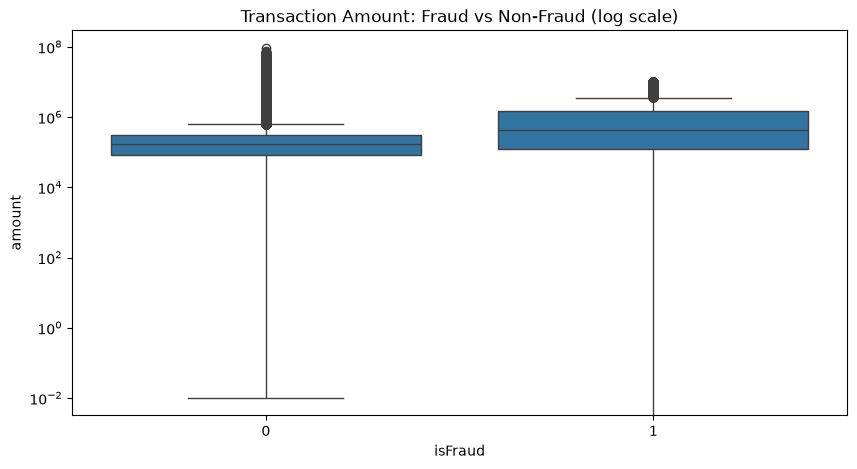

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(x='isFraud', y='amount', data=df[df['type'].isin(['TRANSFER','CASH_OUT'])])
plt.yscale('log')
plt.title('Transaction Amount: Fraud vs Non-Fraud (log scale)')fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Destination balance error
for label, color in [(0, 'steelblue'), (1, 'crimson')]:
    subset = df[df['isFraud'] == label]['dest_balance_error']
    axes[0].hist(subset, bins=100, range=(-1e6, 1e7), alpha=0.5,
                 label=f'isFraud={label}', color=color, density=True)
axes[0].set_title('Destination Balance Error Distribution')
axes[0].set_xlabel('dest_balance_error')
axes[0].legend()

# Origin balance error
for label, color in [(0, 'steelblue'), (1, 'crimson')]:
    subset = df[df['isFraud'] == label]['orig_balance_error']
    axes[1].hist(subset, bins=100, range=(-1e6, 1e6), alpha=0.5,
                 label=f'isFraud={label}', color=color, density=True)
axes[1].set_title('Origin Balance Error Distribution')
axes[1].set_xlabel('orig_balance_error')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.show()

df.groupby('isFraud')['amount'].describe()

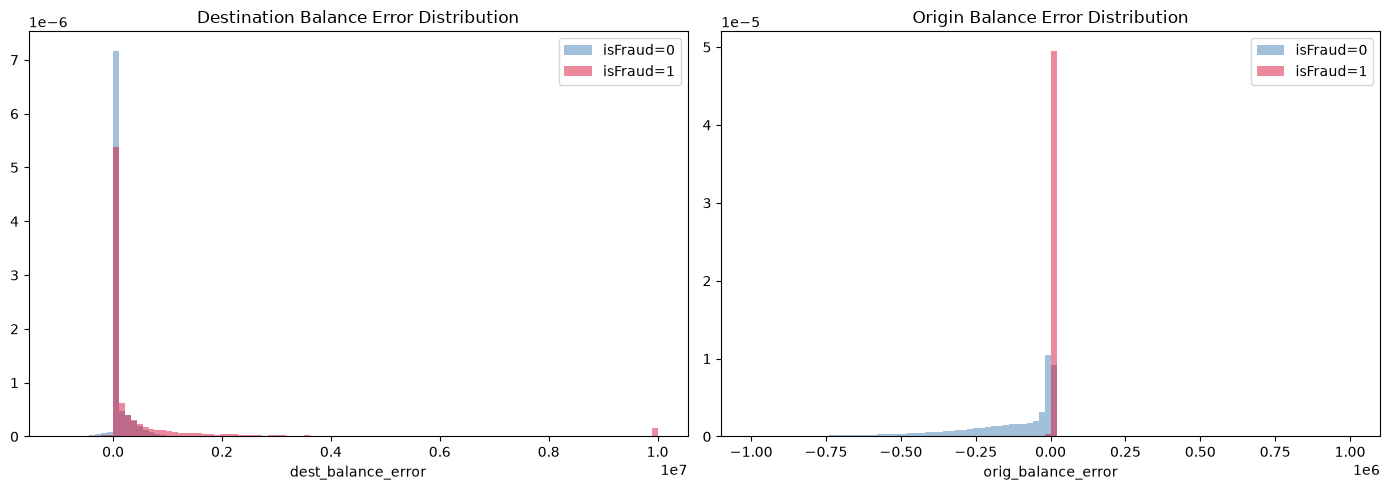

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Destination balance error
for label, color in [(0, 'steelblue'), (1, 'crimson')]:
    subset = df[df['isFraud'] == label]['dest_balance_error']
    axes[0].hist(subset, bins=100, range=(-1e6, 1e7), alpha=0.5,
                 label=f'isFraud={label}', color=color, density=True)
axes[0].set_title('Destination Balance Error Distribution')
axes[0].set_xlabel('dest_balance_error')
axes[0].legend()

# Origin balance error
for label, color in [(0, 'steelblue'), (1, 'crimson')]:
    subset = df[df['isFraud'] == label]['orig_balance_error']
    axes[1].hist(subset, bins=100, range=(-1e6, 1e6), alpha=0.5,
                 label=f'isFraud={label}', color=color, density=True)
axes[1].set_title('Origin Balance Error Distribution')
axes[1].set_xlabel('orig_balance_error')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
fraud_df = df[df['isFraud'] == 1]
print((fraud_df['dest_balance_error'] > 1e6).sum(), "out of", len(fraud_df), "fraud cases have dest_balance_error > 1M")
print(fraud_df['dest_balance_error'].median())  # median instead of mean - less outlier-sensitive

1357 out of 8213 fraud cases have dest_balance_error > 1M
2231.46


In [4]:
# Use only non-fraud transactions to establish what "normal" reconciliation looks like
legit_dest_errors = df[df['isFraud'] == 0]['dest_balance_error']

percentiles = [90, 95, 97, 99, 99.5, 99.9]
for p in percentiles:
    print(f"{p}th percentile: {legit_dest_errors.quantile(p/100):,.2f}")

# Also check the lower tail - errors can be negative too
print(f"\n1st percentile: {legit_dest_errors.quantile(0.01):,.2f}")
print(f"0.1th percentile: {legit_dest_errors.quantile(0.001):,.2f}")

90th percentile: 285,245.64
95th percentile: 455,576.53
97th percentile: 568,296.75
99th percentile: 788,640.33
99.5th percentile: 916,847.38
99.9th percentile: 1,193,103.20

1st percentile: -353,775.55
0.1th percentile: -2,521,742.25


In [20]:
threshold = df[df['isFraud']==0]['dest_balance_error'].quantile(0.99)  # adjust if you pick a different percentile
print(f"Threshold: {threshold:,.2f}")

df['dest_error_flag'] = (df['dest_balance_error'].abs() > threshold).astype(int)

# Check how this flag splits by fraud status
flag_by_fraud = df.groupby('isFraud')['dest_error_flag'].agg(['sum', 'count', 'mean'])
flag_by_fraud.columns = ['flagged_count', 'total_count', 'flag_rate']
print(flag_by_fraud)

print(flag_by_fraud['flag_rate'][1] / flag_by_fraud['flag_rate'][0])

Threshold: 788,640.33
         flagged_count  total_count  flag_rate
isFraud                                       
0                90271      6354407   0.014206
1                 1575         8213   0.191769
13.499121608771407


#### I derived a threshold from the 99th percentile of legitimate transaction behavior, and it alone gives a 13.5x lift in fraud rate"

In [6]:
# Cell 10
df['amount_to_balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)  # +1 avoids divide-by-zero

# Quick sanity check by fraud status
print(df.groupby('isFraud')['amount_to_balance_ratio'].describe())

             count          mean            std           min       25%  \
isFraud                                                                   
0        6354407.0  70764.320934  508745.258992  1.765481e-08  0.233401   
1           8213.0   1161.966671   32297.153000  0.000000e+00  0.999991   

              50%           75%          max  
isFraud                                       
0        6.511566  12355.590000  92445516.64  
1        0.999998      0.999999   1933920.80  


In [7]:
# Cell 11
df['is_transfer_type'] = df['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)

# Confirm this perfectly captures all fraud cases (sanity check against Cell 4's finding)
print(df.groupby('isFraud')['is_transfer_type'].mean())

isFraud
0    0.43469
1    1.00000
Name: is_transfer_type, dtype: float64


* Design decision to note in your README: since 100% of fraud falls in these two types, you have two valid architectural choices:

Option A: Filter the Flink stream to only score TRANSFER/CASH_OUT transactions (cuts ~64% of stream volume from scoring, faster/cheaper at scale)

In [3]:
txn_per_user = df.groupby('nameOrig').size()
print(txn_per_user.describe())
print(f"\nUsers with only 1 transaction: {(txn_per_user == 1).sum()} out of {len(txn_per_user)}")

count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
dtype: float64

Users with only 1 transaction: 6344009 out of 6353307


In [10]:
txn_per_dest = df.groupby('nameDest').size()
print(txn_per_dest.describe())
print(f"\nDest accounts with only 1 transaction: {(txn_per_dest == 1).sum()} out of {len(txn_per_dest)}")

count    2.722362e+06
mean     2.337169e+00
std      4.549264e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.130000e+02
dtype: float64

Dest accounts with only 1 transaction: 2262704 out of 2722362


* "Explored per-account transaction velocity features; found >99% of accounts have a single transaction in this dataset, making rolling window features non-viable. This is a known limitation of PaySim's simulation design and would need to be revisited with a dataset featuring genuine repeat-customer behavior." 

In [11]:
# Cell 14
print(txn_per_dest.describe())
print(f"\nMax transactions to a single dest account: {txn_per_dest.max()}")
print(f"\nDest accounts with 5+ transactions: {(txn_per_dest >= 5).sum()}")
print(f"Dest accounts with 10+ transactions: {(txn_per_dest >= 10).sum()}")

count    2.722362e+06
mean     2.337169e+00
std      4.549264e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.130000e+02
dtype: float64

Max transactions to a single dest account: 113

Dest accounts with 5+ transactions: 280200
Dest accounts with 10+ transactions: 146629


In [12]:
# Cell 15 - does destination transaction count differ for fraud vs non-fraud?
dest_txn_map = txn_per_dest.to_dict()
df['dest_txn_count'] = df['nameDest'].map(dest_txn_map)

print(df.groupby('isFraud')['dest_txn_count'].describe())

             count       mean        std  min  25%  50%   75%    max
isFraud                                                             
0        6354407.0  11.196240  12.397857  1.0  1.0  7.0  17.0  113.0
1           8213.0   8.095337   9.883579  1.0  1.0  4.0  12.0   89.0


In [13]:
# Cell 16
df_sorted_dest = df.sort_values(['nameDest', 'step']).reset_index(drop=True)
df_sorted_dest['dest_txn_count_so_far'] = df_sorted_dest.groupby('nameDest').cumcount()

# Re-check the fraud vs non-fraud split with the leakage-safe version
print(df_sorted_dest.groupby('isFraud')['dest_txn_count_so_far'].describe())

             count      mean       std  min  25%  50%  75%    max
isFraud                                                          
0        6354407.0  5.099214  7.848378  0.0  0.0  2.0  7.0  112.0
1           8213.0  2.701327  5.984213  0.0  0.0  0.0  3.0   61.0


In [16]:
# Cell 17 - consolidate into a clean modeling dataframe
df_final = df_sorted_dest.copy()

threshold = 788640.33
df_final['dest_error_flag'] = (df_final['dest_balance_error'].abs() > threshold).astype(int)
df_final['is_transfer_type'] = df_final['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)
df_final['amount_to_balance_ratio'] = df_final['amount'] / (df_final['oldbalanceOrg'] + 1)

feature_cols = [
    'dest_balance_error', 'dest_error_flag', 'orig_balance_error',
    'is_transfer_type', 'amount_to_balance_ratio', 'dest_txn_count_so_far',
    'amount'  # keep raw amount too, it's a baseline signal on its own
]

model_df = df_final[df_final['is_transfer_type'] == 1][feature_cols + ['isFraud', 'step']].copy()
print(model_df.shape)
print(model_df['isFraud'].value_counts())

(2770409, 9)
isFraud
0    2762196
1       8213
Name: count, dtype: int64


In [18]:
# Cell 18
model_df_sorted = model_df.sort_values('step').reset_index(drop=True)

split_step = model_df_sorted['step'].quantile(0.8)
print(f"Splitting at step: {split_step}")

train_df = model_df_sorted[model_df_sorted['step'] <= split_step]
test_df = model_df_sorted[model_df_sorted['step'] > split_step]

print(f"Train: {train_df.shape}, fraud rate: {train_df['isFraud'].mean():.4f}")
print(f"Test: {test_df.shape}, fraud rate: {test_df['isFraud'].mean():.4f}")

X_train = train_df.drop(columns=['isFraud', 'step'])
y_train = train_df['isFraud']
X_test = test_df.drop(columns=['isFraud', 'step'])
y_test = test_df['isFraud']

Splitting at step: 354.0
Train: (2217905, 9), fraud rate: 0.0018
Test: (552504, 9), fraud rate: 0.0077


count    743.000000
mean       0.449681
std        0.482382
min        0.000000
25%        0.001984
50%        0.086207
75%        1.000000
max        1.000000
Name: mean, dtype: float64


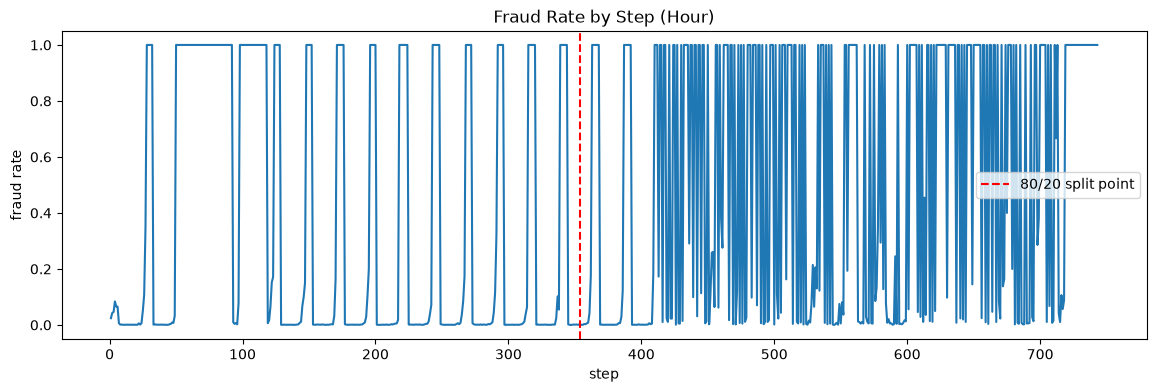

In [19]:
# Cell 22
fraud_by_step = model_df_sorted.groupby('step')['isFraud'].agg(['sum', 'count', 'mean'])
print(fraud_by_step['mean'].describe())

# Visualize
plt.figure(figsize=(14,4))
plt.plot(fraud_by_step.index, fraud_by_step['mean'])
plt.axvline(x=354, color='red', linestyle='--', label='80/20 split point')
plt.title('Fraud Rate by Step (Hour)')
plt.xlabel('step')
plt.ylabel('fraud rate')
plt.legend()
plt.show()

count      743.000000
mean      3728.679677
std       6090.730170
min          2.000000
25%         12.000000
50%        112.000000
75%       3998.500000
max      23768.000000
dtype: float64


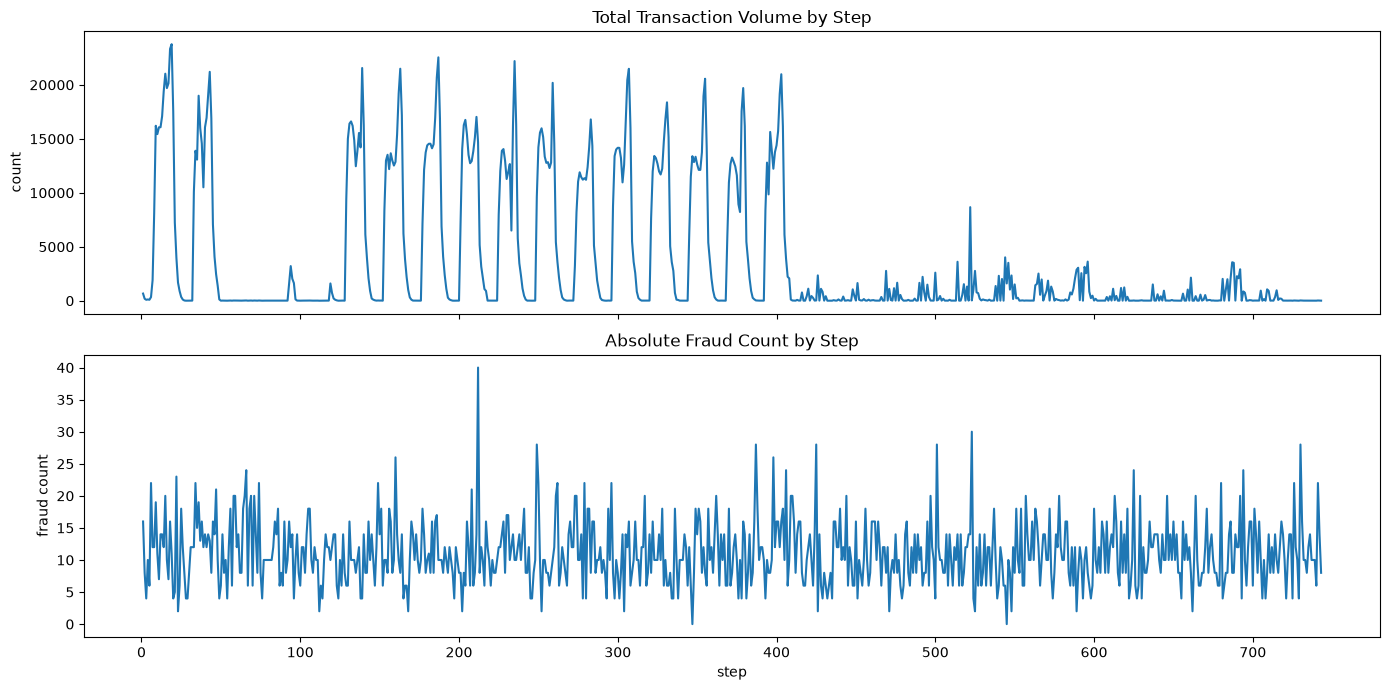

In [12]:
# Cell 23
step_volume = model_df_sorted.groupby('step').size()
print(step_volume.describe())

fig, axes = plt.subplots(2, 1, figsize=(14,7), sharex=True)
axes[0].plot(fraud_by_step.index, fraud_by_step['count'])
axes[0].set_title('Total Transaction Volume by Step')
axes[0].set_ylabel('count')

axes[1].plot(fraud_by_step.index, fraud_by_step['sum'])
axes[1].set_title('Absolute Fraud Count by Step')
axes[1].set_ylabel('fraud count')
axes[1].set_xlabel('step')

plt.tight_layout()
plt.show()

#### Two very different regimes in this data:

Steps 0-400: Transaction volume is highly bursty — cycling between ~15,000-23,000 transactions per step and near-zero, in a repeating pattern (this looks like daily cycles: high activity "daytime" bursts, quiet "nighttime" troughs)
Steps 400+: Volume collapses to a low, noisy baseline — rarely above a few thousand, often under 1,000

In [23]:
# Cell 26
import numpy as np

max_step = model_df_sorted['step'].max()
print(f"Max step: {max_step}")

# Define 5 walk-forward folds, expanding training window each time
n_folds = 5
fold_boundaries = np.linspace(model_df_sorted['step'].min(), max_step, n_folds + 2)
print("Fold boundaries:", fold_boundaries)

Max step: 743
Fold boundaries: [  1.         124.66666667 248.33333333 372.         495.66666667
 619.33333333 743.        ]


In [21]:
# Cell 27 - Walk-forward validation loop
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score
results = []

for i in range(1, n_folds + 1):
    train_end = fold_boundaries[i]
    test_end = fold_boundaries[i + 1]

    fold_train = model_df_sorted[model_df_sorted['step'] <= train_end]
    fold_test = model_df_sorted[(model_df_sorted['step'] > train_end) & (model_df_sorted['step'] <= test_end)]

    if fold_test['isFraud'].sum() < 5:  # skip folds with too few fraud cases to evaluate meaningfully
        print(f"Fold {i}: skipped, only {fold_test['isFraud'].sum()} fraud cases in test window")
        continue

    X_tr = fold_train.drop(columns=['isFraud', 'step'])
    y_tr = fold_train['isFraud']
    X_te = fold_test.drop(columns=['isFraud', 'step'])
    y_te = fold_test['isFraud']

    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=spw, eval_metric='aucpr', random_state=42
    )
    model.fit(X_tr, y_tr)

    probs = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, probs)
    pr_auc = average_precision_score(y_te, probs)

    fold_result = {
        'fold': i,
        'train_size': len(fold_train),
        'test_size': len(fold_test),
        'train_fraud_rate': y_tr.mean(),
        'test_fraud_rate': y_te.mean(),
        'auc': auc,
        'pr_auc': pr_auc
    }
    results.append(fold_result)
    print(fold_result)

results_df = pd.DataFrame(results)
print("\n--- Summary ---")
print(results_df[['auc', 'pr_auc']].agg(['mean', 'std']))

{'fold': 1, 'train_size': 466171, 'test_size': 932761, 'train_fraud_rate': np.float64(0.0030932855111107296), 'test_fraud_rate': np.float64(0.001446244000338779), 'auc': 0.9989796424789066, 'pr_auc': 0.9821284084830847}
{'fold': 2, 'train_size': 1398932, 'test_size': 909288, 'train_fraud_rate': np.float64(0.00199509339982215), 'test_fraud_rate': np.float64(0.0014978752606434925), 'auc': 0.9999178344708002, 'pr_auc': 0.9893954166374891}
{'fold': 3, 'train_size': 2308220, 'test_size': 334570, 'train_fraud_rate': np.float64(0.0017992219112562928), 'test_fraud_rate': np.float64(0.004052963505394984), 'auc': 0.9999761264090067, 'pr_auc': 0.9959804417464666}
{'fold': 4, 'train_size': 2642790, 'test_size': 89136, 'train_fraud_rate': np.float64(0.002084539445056172), 'test_fraud_rate': np.float64(0.01492101956560761), 'auc': 0.9998953905388486, 'pr_auc': 0.9984434790846214}
{'fold': 5, 'train_size': 2731926, 'test_size': 38483, 'train_fraud_rate': np.float64(0.0025033620969235624), 'test_fraud

In [22]:
# Cell 28 - check for near-deterministic separation
fraud_only = model_df_sorted[model_df_sorted['isFraud'] == 1]
legit_only = model_df_sorted[model_df_sorted['isFraud'] == 0]

for col in ['dest_balance_error', 'orig_balance_error', 'dest_error_flag', 'amount_to_balance_ratio']:
    print(f"\n--- {col} ---")
    print(f"Fraud:  {fraud_only[col].describe()}")
    print(f"Legit:  {legit_only[col].describe()}")


--- dest_balance_error ---
Fraud:  count    8.213000e+03
mean     7.325093e+05
std      1.867748e+06
min     -8.875516e+06
25%      0.000000e+00
50%      2.231460e+03
75%      4.427220e+05
max      1.000000e+07
Name: dest_balance_error, dtype: float64
Legit:  count    2.762196e+06
mean    -3.091033e+04
std      5.840943e+05
min     -7.588573e+07
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.977761e+06
Name: dest_balance_error, dtype: float64

--- orig_balance_error ---
Fraud:  count    8.213000e+03
mean    -1.069233e+04
std      2.651461e+05
min     -1.000000e+07
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.725290e-09
Name: orig_balance_error, dtype: float64
Legit:  count    2.762196e+06
mean    -2.868035e+05
std      8.763752e+05
min     -9.244552e+07
25%     -2.804663e+05
50%     -1.442008e+05
75%     -5.261343e+04
max      1.000000e-02
Name: orig_balance_error, dtype: float64

--- dest_error_flag ---
Fraud:  count    82

In [23]:
# Cell 29 - the real test: does newbalanceDest itself trivially separate fraud?
print(df_final.groupby('isFraud')['newbalanceDest'].describe())
print("\nHow many fraud cases have newbalanceDest == 0 or == oldbalanceDest (unchanged)?")
fraud_check = df_final[df_final['isFraud']==1]
unchanged = (fraud_check['newbalanceDest'] == fraud_check['oldbalanceDest']).sum()
print(f"{unchanged} out of {len(fraud_check)} fraud cases show unchanged destination balance")

             count          mean           std  min  25%        50%  \
isFraud                                                               
0        6354407.0  1.224926e+06  3.673816e+06  0.0  0.0  214881.70   
1           8213.0  1.279708e+06  3.908817e+06  0.0  0.0    4676.42   

                 75%           max  
isFraud                             
0        1111975.345  3.561793e+08  
1        1058725.220  2.367265e+08  

How many fraud cases have newbalanceDest == 0 or == oldbalanceDest (unchanged)?
4086 out of 8213 fraud cases show unchanged destination balance


In [24]:
# Cell 30 - single-feature AUC check (isolates whether ONE feature alone is doing all the work)
from sklearn.metrics import roc_auc_score

for col in ['dest_balance_error', 'orig_balance_error', 'dest_error_flag', 'amount_to_balance_ratio', 'dest_txn_count_so_far', 'amount']:
    auc_single = roc_auc_score(model_df_sorted['isFraud'], model_df_sorted[col])
    print(f"{col}: single-feature AUC = {auc_single:.4f}")

dest_balance_error: single-feature AUC = 0.7486
orig_balance_error: single-feature AUC = 0.9466
dest_error_flag: single-feature AUC = 0.5918
amount_to_balance_ratio: single-feature AUC = 0.1005
dest_txn_count_so_far: single-feature AUC = 0.2315
amount: single-feature AUC = 0.6834


In [25]:
# Cell 31 - verify the zero-balance hypothesis
legit_transfer = model_df_sorted[model_df_sorted['isFraud']==0]
zero_balance_legit = ((df_final['oldbalanceOrg']==0) & (df_final['newbalanceOrig']==0) & (df_final['isFraud']==0)).sum()
total_legit = (df_final['isFraud']==0).sum()
print(f"Legit txns with both orig balances = 0: {zero_balance_legit} out of {total_legit} ({100*zero_balance_legit/total_legit:.1f}%)")

fraud_exact_zero_error = ((df_final['orig_balance_error'].abs() < 0.01) & (df_final['isFraud']==1)).sum()
total_fraud = (df_final['isFraud']==1).sum()
print(f"Fraud txns with orig_balance_error ≈ 0: {fraud_exact_zero_error} out of {total_fraud} ({100*fraud_exact_zero_error/total_fraud:.1f}%)")

Legit txns with both orig balances = 0: 2088944 out of 6354407 (32.9%)
Fraud txns with orig_balance_error ≈ 0: 8168 out of 8213 (99.5%)


In [25]:
# Cell 32
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score
clean_features = [
    'is_transfer_type', 'amount_to_balance_ratio', 
    'dest_txn_count_so_far', 'amount'
]

# Quick single-feature AUC recap for the clean set (already have most of these from Cell 30)
print("Clean feature single-AUCs:")
for col in clean_features:
    auc_single = roc_auc_score(model_df_sorted['isFraud'], model_df_sorted[col])
    print(f"  {col}: {auc_single:.4f}")

Clean feature single-AUCs:
  is_transfer_type: 0.5000
  amount_to_balance_ratio: 0.1005
  dest_txn_count_so_far: 0.2315
  amount: 0.6834


In [26]:
# Cell 33 - re-run walk-forward validation with the clean feature set
results_clean = []

for i in range(1, n_folds + 1):
    train_end = fold_boundaries[i]
    test_end = fold_boundaries[i + 1]

    fold_train = model_df_sorted[model_df_sorted['step'] <= train_end]
    fold_test = model_df_sorted[(model_df_sorted['step'] > train_end) & (model_df_sorted['step'] <= test_end)]

    if fold_test['isFraud'].sum() < 5:
        continue

    X_tr = fold_train[clean_features]
    y_tr = fold_train['isFraud']
    X_te = fold_test[clean_features]
    y_te = fold_test['isFraud']

    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

    model_clean = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=spw, eval_metric='aucpr', random_state=42
    )
    model_clean.fit(X_tr, y_tr)

    probs = model_clean.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, probs)
    pr_auc = average_precision_score(y_te, probs)

    results_clean.append({'fold': i, 'auc': auc, 'pr_auc': pr_auc,
                            'test_fraud_rate': y_te.mean()})
    print(results_clean[-1])

results_clean_df = pd.DataFrame(results_clean)
print("\n--- Clean Model Summary ---")
print(results_clean_df[['auc', 'pr_auc']].agg(['mean', 'std']))

{'fold': 1, 'auc': 0.9989199795229, 'pr_auc': 0.9196821348868264, 'test_fraud_rate': np.float64(0.001446244000338779)}
{'fold': 2, 'auc': 0.9995180278119984, 'pr_auc': 0.8704721655590485, 'test_fraud_rate': np.float64(0.0014978752606434925)}
{'fold': 3, 'auc': 0.9996345749300374, 'pr_auc': 0.9344755438583062, 'test_fraud_rate': np.float64(0.004052963505394984)}
{'fold': 4, 'auc': 0.9997380289322034, 'pr_auc': 0.982015372847996, 'test_fraud_rate': np.float64(0.01492101956560761)}
{'fold': 5, 'auc': 0.9996297739343983, 'pr_auc': 0.9913594171003991, 'test_fraud_rate': np.float64(0.03570407712496427)}

--- Clean Model Summary ---
           auc    pr_auc
mean  0.999488  0.939601
std   0.000327  0.049193


In [27]:
# Cell 34 - which clean feature is carrying the model?
model_clean.fit(model_df_sorted[clean_features], model_df_sorted['isFraud'])
importance_clean = pd.Series(model_clean.feature_importances_, index=clean_features).sort_values(ascending=False)
print(importance_clean)

amount_to_balance_ratio    0.959282
amount                     0.035308
dest_txn_count_so_far      0.005410
is_transfer_type           0.000000
dtype: float32


In [28]:
# Cell 35 - persist the final model and threshold info for later use (Kafka producer, Flink job)
import pickle

final_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=(model_df_sorted['isFraud']==0).sum() / (model_df_sorted['isFraud']==1).sum(),
    eval_metric='aucpr', random_state=42
)
final_model.fit(model_df_sorted[clean_features], model_df_sorted['isFraud'])

with open('../models/fraud_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('../models/feature_list.pkl', 'wb') as f:
    pickle.dump(clean_features, f)

print("Model and feature list saved.")

Model and feature list saved.
